# Reznar's Catalog: Spotting Mispriced Items

Reznar suspects some items sit in the wrong rarity tier. This report checks that suspicion in two steps:

1. **Learn the pattern.** Train models to predict an item's rarity from its recorded traits: attack and defense bonuses, attunement, special effects, drawbacks, and so on.
2. **Flag the mismatches.** Items whose traits point to a very different tier than their label are the anomalies worth a second look.

The catalog has only 79 usable items, so we rely on simple, transparent models and judge them mainly on whether they rank items in the right order, not on raw accuracy alone.

In [54]:
import db
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. The data

We pull the extracted catalog from Postgres. One item, *Pouch of False Coins*, came through extraction with no usable fields, so it is dropped, leaving 79 items.

In [55]:
with db.connect() as conn:
    df = pd.read_sql("SELECT * FROM items", conn)

# Pouch of False Coins is a known mis-extraction (no usable fields)
df = df[df["name"] != "Pouch of False Coins"].reset_index(drop=True)
print(df.shape)
df.head()

(79, 16)


/var/folders/1b/7qkztt_97sl2fl6cgw4fbj1h0000gn/T/ipykernel_35655/3098623631.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM items", conn)


,name,form,slot,rarity,req_attunement,offense_attack_damage_bonus,offense_effective_against,defense_ac_bonus,defense_condition_immunities,defense_resistances_against,defense_damage_resistances,environment_strong_in,limitations_charges,limitations_cursed,limitations_drawbacks,special_effects
0,Headband of Martial Prowess,headband,head,rare,True,2,[],0,[],[],[],[],NaN,False,[],[grants proficiency in martial weapons (or +2 ...
1,Mask of Devil Control,mask,head,legendary,True,0,[fiend],0,[],[],[],[],NaN,False,[],[Dominate one fiend within 60 ft (Wisdom save ...
2,Pipe of Controlling Winds,wondrous,none,rare,False,0,[],0,[],[],[],[],1.0,False,[24 hours must pass before summoning another e...,[summons a large air elemental under your cont...
3,Armor of Daylight's Embrace,armor,body,rare,True,0,[vampire],0,[charmed],[vampire],[necrotic],[],NaN,False,[],[deals 20 radiant damage every round while a v...
4,Armor of Increased Aptitude,armor,body,very_rare,True,0,[],2,[],[],[],[],1.0,False,[can only activate one ability per short or lo...,[grants +2 to all saving throws and ability ch...


## 2. What the catalog looks like

Two things to check before modeling: how the rarity tiers are distributed (some are far rarer than others), and whether an item's power traits actually rise with its tier.

rarity
uncommon      9
rare         28
very_rare    29
legendary     9
artifact      4


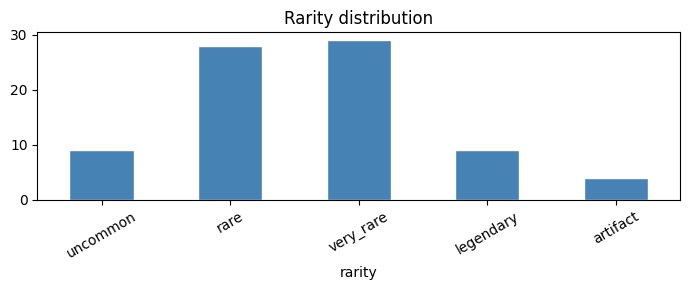

In [56]:
RARITY_ORDER = ["uncommon", "rare", "very_rare", "legendary", "artifact"]

counts = df["rarity"].value_counts().reindex(RARITY_ORDER).fillna(0).astype(int)
print(counts.to_string())

counts.plot(kind="bar", color="steelblue", edgecolor="white", figsize=(7, 3))
plt.title("Rarity distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

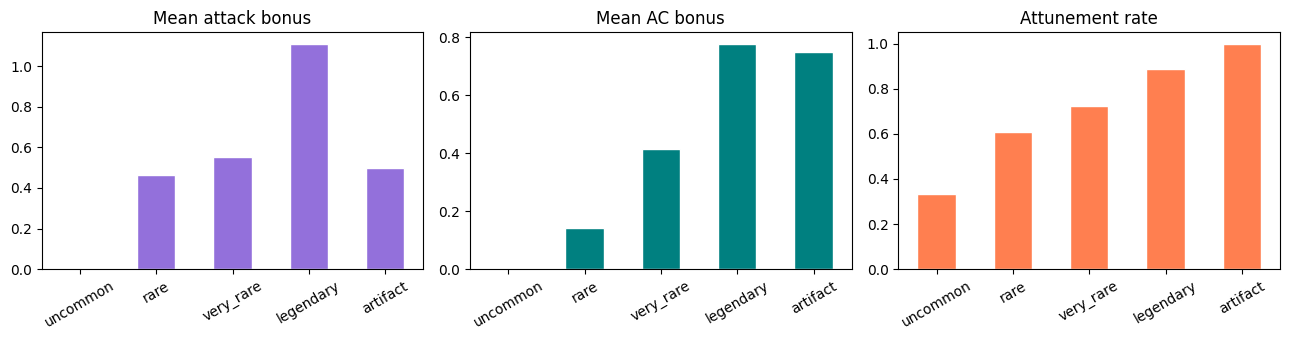

In [57]:
df_ord = df[df["rarity"].isin(RARITY_ORDER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
df_ord.groupby("rarity")["offense_attack_damage_bonus"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[0], color="mediumpurple", edgecolor="white"
)
df_ord.groupby("rarity")["defense_ac_bonus"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[1], color="teal", edgecolor="white"
)
df_ord.groupby("rarity")["req_attunement"].mean().reindex(RARITY_ORDER).plot(
    kind="bar", ax=axes[2], color="coral", edgecolor="white"
)
for ax, title in zip(axes, ["Mean attack bonus", "Mean AC bonus", "Attunement rate"]):
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

The tiers are unbalanced: `rare` and `very_rare` hold most of the catalog, while `legendary` and `artifact` have only a handful of items each. The trait averages generally rise with rarity, confirming the structured fields carry real signal for the model to use.

## 3. From items to features

Each item becomes a row of numbers the models can read:

- **Numeric traits** kept directly: attack bonus, AC bonus, charges, attunement, cursed.
- **List traits** (effective-against, immunities, resistances, environments, drawbacks, special effects) turned into counts of how many entries each item has.

Items labeled `varies` do not sit on the rarity ladder, so they are set aside; the five ordered tiers (`uncommon` through `artifact`) are what we model.

We then screen the features two ways: how strongly each one tracks rarity, and how much they overlap each other. Overlapping (collinear) features add noise without new signal, so we cut them using a correlation cutoff and the Variance Inflation Factor (VIF).

In [58]:
LIST_COLS = [
    "offense_effective_against",
    "defense_condition_immunities",
    "defense_resistances_against",
    "defense_damage_resistances",
    "environment_strong_in",
    "limitations_drawbacks",
    "special_effects",
]

# Keep only the ordered rarities; 'varies' is set aside, not modeled
df_model = df[df["rarity"].isin(RARITY_ORDER)].reset_index(drop=True)

features = pd.DataFrame(index=df_model.index)
features["attack_bonus"] = df_model["offense_attack_damage_bonus"].fillna(0).astype(int)
features["ac_bonus"] = df_model["defense_ac_bonus"].fillna(0).astype(int)
features["charges"] = df_model["limitations_charges"].fillna(0).astype(int)
features["req_attunement"] = df_model["req_attunement"].astype(int)
features["cursed"] = df_model["limitations_cursed"].astype(int)

for col in LIST_COLS:
    features[f"n_{col.split('_', 1)[1]}"] = df_model[col].apply(
        lambda x: len(x) if x is not None else 0
    )


features["rarity_ord"] = df_model["rarity"].map({r: i for i, r in enumerate(RARITY_ORDER)})

print(features.shape)
features.head()

(79, 13)


,attack_bonus,ac_bonus,charges,req_attunement,cursed,n_effective_against,n_condition_immunities,n_resistances_against,n_damage_resistances,n_strong_in,n_drawbacks,n_effects,rarity_ord
0,2,0,0,1,0,0,0,0,0,0,0,1,1
1,0,0,0,1,0,1,0,0,0,0,0,4,3
2,0,0,1,0,0,0,0,0,0,0,1,2,1
3,0,0,0,1,0,1,1,1,1,0,0,2,1
4,0,2,1,1,0,0,0,0,0,0,1,4,2


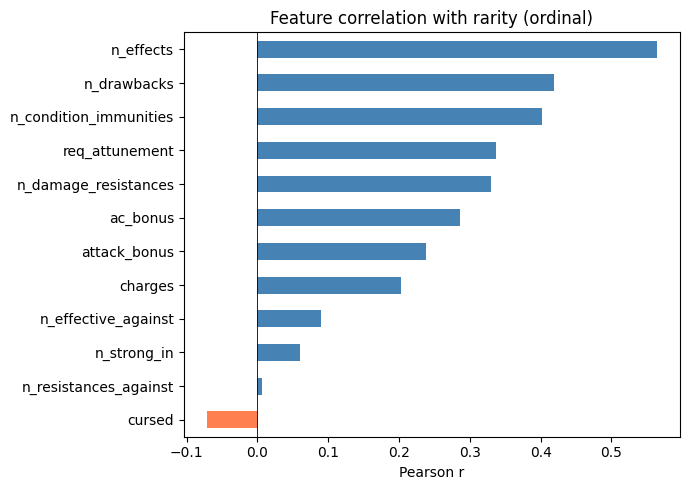

In [59]:
target_corr = features.corr(numeric_only=True)["rarity_ord"].drop("rarity_ord").sort_values()

plt.figure(figsize=(7, 5))
target_corr.plot(kind="barh", color=["coral" if v < 0 else "steelblue" for v in target_corr])
plt.axvline(0, color="black", linewidth=0.6)
plt.title("Feature correlation with rarity (ordinal)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

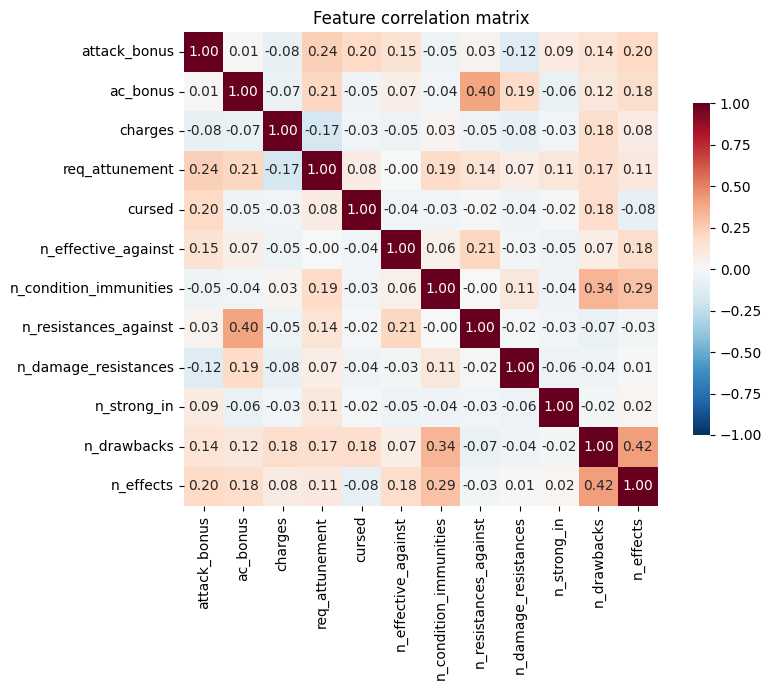

In [60]:
X = features.drop(columns="rarity_ord")
corr = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7},
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [61]:
THRESHOLD = 0.80

upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
pairs = (
    upper.stack()
    .pipe(lambda s: s[s.abs() > THRESHOLD])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(f"Pairs with |r| > {THRESHOLD}:")
print(pairs.to_string() if len(pairs) else "  (none)")

# From each collinear pair, drop the feature with weaker correlation to the target
to_drop: set[str] = set()
for (a, b), _ in pairs.items():
    if a in to_drop or b in to_drop:
        continue
    drop = a if abs(target_corr[a]) < abs(target_corr[b]) else b
    to_drop.add(drop)

print(f"\nDropping: {sorted(to_drop)}")
X_pearson = X.drop(columns=list(to_drop))
print(f"Surviving features ({X_pearson.shape[1]}): {list(X_pearson.columns)}")

Pairs with |r| > 0.8:
  (none)

Dropping: []
Surviving features (12): ['attack_bonus', 'ac_bonus', 'charges', 'req_attunement', 'cursed', 'n_effective_against', 'n_condition_immunities', 'n_resistances_against', 'n_damage_resistances', 'n_strong_in', 'n_drawbacks', 'n_effects']


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X: pd.DataFrame) -> pd.Series:
    Xc = pd.concat([pd.Series(1.0, index=X.index, name="const"), X], axis=1)
    return pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=X.columns,
    ).sort_values(ascending=False)


X_final = X_pearson.copy()
dropped: list[str] = []
while X_final.shape[1] >= 2:
    vif = compute_vif(X_final)
    worst, worst_v = vif.index[0], vif.iloc[0]
    if not np.isfinite(worst_v) or worst_v > 5.0:
        dropped.append(f"{worst} (VIF={worst_v:.1f})")
        X_final = X_final.drop(columns=worst)
    else:
        break

print(f"Dropped {len(dropped)} feature(s): {dropped}")
print(f"\nFinal VIF ({X_final.shape[1]} features):")
print(compute_vif(X_final).round(2).to_string())

Dropped 0 feature(s): []

Final VIF (12 features):
n_drawbacks               1.49
ac_bonus                  1.43
n_effects                 1.42
n_resistances_against     1.33
n_condition_immunities    1.30
req_attunement            1.25
attack_bonus              1.23
cursed                    1.13
n_effective_against       1.12
n_damage_resistances      1.10
charges                   1.10
n_strong_in               1.04


With the screen complete, we lock in the final model inputs: the feature matrix `X`, the rarity target `y` (encoded 0 to 4), and the item names for labeling results later.

In [63]:
X = X_final.to_numpy(dtype=float)
y = features["rarity_ord"].to_numpy(dtype=int)
names = df_model["name"].to_numpy()

n_varies = (df["rarity"] == "varies").sum()
print(f"X shape: {X.shape}")
print("class counts:", {RARITY_ORDER[k]: int(v) for k, v in pd.Series(y).value_counts().sort_index().items()})

X shape: (79, 12)
class counts: {'uncommon': 9, 'rare': 28, 'very_rare': 29, 'legendary': 9, 'artifact': 4}


## 4. Predicting rarity

Two facts about this data shape every choice below:

1. **Rarity is ordered:** `uncommon < rare < very_rare < legendary < artifact`. Predicting `legendary` when the truth is `artifact` is a near miss; predicting `uncommon` is a serious one. A good model should treat those differently.
2. **The labels may be wrong.** Reznar suspects some items are mis-tiered, so when a model disagrees with a label we cannot assume the model is at fault. Surfacing that tension is the goal.

We try three ways to frame the prediction, plus a baseline:

- **Regression** (Random Forest and Ridge): predict rarity as a number on a 0 to 4 scale, which keeps the *distance* between tiers.
- **Unordered classifier** (Random Forest): five separate buckets, blind to the ordering.
- **Ordinal model** (ordinal logistic regression, OLR): built for ranked categories.
- **Baseline**: always predicts the average rarity. Any real model must beat it; a model that cannot outperform "always guess the middle" has learned nothing.

Every model runs through the **same out-of-fold protocol**: each item's score comes from a model trained on the other items, so no model is graded on data it has seen. We stay with simple models because with only 79 items, anything more flexible would just memorize the noise.

In [64]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import cohen_kappa_score, confusion_matrix, mean_absolute_error
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mord import LogisticAT
from scipy import stats

K = len(RARITY_ORDER)


def oof_predict(estimator_factory, X, y, weight_key="sample_weight",
                n_splits=4, n_repeats=10, seed=0):
    """OOF predictions, averaged across repeats. Each fold fits a fresh model on the
    training rows and predicts the held-out rows, so every item's score comes from a
    model that never saw it. Inverse-frequency sample weights handle class imbalance."""
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    preds = np.zeros((n_repeats, len(y)))
    for fold_i, (tr, te) in enumerate(cv.split(X, y)):
        rep = fold_i // n_splits
        cls_counts = np.bincount(y[tr])
        w = 1.0 / cls_counts[y[tr]]
        est = estimator_factory()
        est.fit(X[tr], y[tr], **{weight_key: w})
        preds[rep, te] = est.predict(X[te])  # te is held out this fold, so this is OOF
    return preds.mean(axis=0), preds


# One factory per framing, every model scored by its own .predict() through one harness:
#   RF-reg / Ridge : regression on the 0 to 4 scale (keeps the distance of an error)
#   RF-clf         : unordered five-class classifier (blind to ordering)
#   OLR            : All-Threshold ordinal logit (ordinal-native, shared slopes)
#   Baseline       : always predicts the mean rarity
rf_factory    = lambda: RandomForestRegressor(min_samples_leaf=4, random_state=0, n_jobs=-1, criterion="absolute_error")
ridge_factory = lambda: Pipeline([("sc", StandardScaler()), ("ridge", Ridge(alpha=0.5))])
rfclf_factory = lambda: RandomForestClassifier(max_depth=2, min_samples_leaf=4, random_state=0, n_jobs=-1)
olr_factory   = lambda: Pipeline([("sc", StandardScaler()), ("olr", LogisticAT(alpha=1.0))])

# name -> (factory, weight_key)
MODELS = {
    "Baseline": (lambda: DummyRegressor(strategy="mean"), "sample_weight"),
    "RF-reg":   (rf_factory,                              "sample_weight"),
    "Ridge":    (ridge_factory,                           "ridge__sample_weight"),
    "RF-clf":   (rfclf_factory,                           "sample_weight"),
    "OLR":      (olr_factory,                             "olr__sample_weight"),
}

scores = {nm: oof_predict(f, X, y, weight_key=wk)[0] for nm, (f, wk) in MODELS.items()}

def metrics(s):
    r = np.clip(np.round(s), 0, K - 1).astype(int)
    macro_mae = np.mean([mean_absolute_error(y[y == k], r[y == k]) for k in range(K) if (y == k).any()])
    return {
        "macro_MAE": macro_mae,
        "QWK":       cohen_kappa_score(y, r, weights="quadratic"),
        "spearman":  0.0 if np.std(s) == 0 else stats.spearmanr(y, s).statistic,  # const baseline is undefined
        "±1_acc":    np.mean(np.abs(y - r) <= 1),
    }


summary = pd.DataFrame({nm: metrics(s) for nm, s in scores.items()}).T
print("OOF metrics (every model must beat Baseline):")
print(summary.round(3).to_string())

# Per-class directional bias (the headline averages above hide tail bias)
signed = pd.DataFrame({nm: [(scores[nm][y == k] - y[y == k]).mean() for k in range(K)] for nm in MODELS}, index=RARITY_ORDER)
mean_pred = pd.DataFrame({nm: [scores[nm][y == k].mean() for k in range(K)] for nm in MODELS}, index=RARITY_ORDER)
print("\nPer-class signed residual (pred - true;  >0 over-, <0 under-predicts):")
print(signed.round(2).to_string())
print("\nPer-class mean prediction:")
print(mean_pred.round(2).to_string())

OOF metrics (every model must beat Baseline):
          macro_MAE    QWK  spearman  ±1_acc
Baseline      1.200  0.000     0.000   0.835
RF-reg        0.655  0.610     0.570   0.937
Ridge         0.579  0.677     0.615   0.975
RF-clf        0.654  0.567     0.554   0.873
OLR           0.529  0.681     0.629   0.962

Per-class signed residual (pred - true;  >0 over-, <0 under-predicts):
           Baseline  RF-reg  Ridge  RF-clf   OLR
uncommon        2.0    0.65   0.83    0.24  0.63
rare            1.0    0.29   0.29   -0.11  0.28
very_rare       0.0   -0.31  -0.41   -0.66 -0.33
legendary      -1.0   -0.85  -0.60   -1.00 -0.54
artifact       -2.0   -0.77  -0.06    0.00 -0.32

Per-class mean prediction:
           Baseline  RF-reg  Ridge  RF-clf   OLR
uncommon        2.0    0.65   0.83    0.24  0.63
rare            2.0    1.29   1.29    0.89  1.27
very_rare       2.0    1.69   1.59    1.34  1.67
legendary       2.0    2.15   2.40    2.00  2.46
artifact        2.0    3.23   3.94    4.00  3

**Reading the table.** The headline metrics are **±1-accuracy** (how often the prediction lands within one tier of the truth) and **ranking ability** (QWK and Spearman: whether items come out in the right order). Since the deliverable is a ranked anomaly list, ranking matters most. **macro-MAE** (average distance from the truth) is a secondary tie-breaker.

The **per-class signed residual** shows the *direction* of each model's bias: a model can look fine on average while quietly under-rating every `artifact`. That is what catches tail bias.

All four real models clear the baseline.

In [65]:
# Error analysis across the three regression-framing models.
# Two Pearson views: raw predictions (do they agree?) and residuals/errors
# (do they make the SAME mistakes?). The error view is what matters for ensemble
# diversity: averaging two models that err identically buys nothing.
REG_MODELS = ["RF-reg", "Ridge", "OLR"]

preds_df = pd.DataFrame({m: scores[m] for m in REG_MODELS})
resid_df = preds_df.sub(y, axis=0)  # signed error = pred - true

pred_corr = preds_df.corr()
err_corr = resid_df.corr()

print("Pearson r - predictions:")
print(pred_corr.round(3).to_string())
print("\nPearson r - errors (residuals):")
print(err_corr.round(3).to_string())

Pearson r - predictions:
        RF-reg  Ridge    OLR
RF-reg   1.000  0.844  0.878
Ridge    0.844  1.000  0.944
OLR      0.878  0.944  1.000

Pearson r - errors (residuals):
        RF-reg  Ridge    OLR
RF-reg   1.000  0.804  0.840
Ridge    0.804  1.000  0.914
OLR      0.840  0.914  1.000


## 5. Choosing the final model

Before combining models, we check whether they make *different* mistakes. Averaging two models that err the same way buys nothing.

Ridge and OLR turn out to be near-redundant: their predictions correlate at r=0.94 and, more tellingly, their errors at r=0.91, meaning they get the same items wrong in the same direction. Both are linear in the same features, so this is expected, and they score almost identically. Only one belongs in the ensemble, and we keep **OLR** because it is built for ranked categories and respects the tier ordering by construction.

That leaves **OLR** paired with **RF-reg**, the non-linear tree model. These two have the lowest error correlation of the group (r=0.84), so they are genuinely different approaches, which is the whole point of averaging them.

In [66]:
# Averaging ensemble of the two diverse survivors: simple unweighted mean of the
# RF-reg and OLR OOF scores. Re-run the exact same diagnostics so it lands in the
# same table as every rival.
scores["Ensemble"] = (scores["RF-reg"] + scores["OLR"]) / 2

summary = pd.DataFrame({nm: metrics(s) for nm, s in scores.items()}).T
print("OOF metrics (Ensemble vs all):")
print(summary.round(3).to_string())

signed = pd.DataFrame(
    {nm: [(scores[nm][y == k] - y[y == k]).mean() for k in range(K)] for nm in scores},
    index=RARITY_ORDER,
)
mean_pred = pd.DataFrame(
    {nm: [scores[nm][y == k].mean() for k in range(K)] for nm in scores},
    index=RARITY_ORDER,
)
print("\nPer-class signed residual (pred - true;  >0 over-, <0 under-predicts):")
print(signed.round(2).to_string())
print("\nPer-class mean prediction:")
print(mean_pred.round(2).to_string())

OOF metrics (Ensemble vs all):
          macro_MAE    QWK  spearman  ±1_acc
Baseline      1.200  0.000     0.000   0.835
RF-reg        0.655  0.610     0.570   0.937
Ridge         0.579  0.677     0.615   0.975
RF-clf        0.654  0.567     0.554   0.873
OLR           0.529  0.681     0.629   0.962
Ensemble      0.606  0.664     0.605   0.975

Per-class signed residual (pred - true;  >0 over-, <0 under-predicts):
           Baseline  RF-reg  Ridge  RF-clf   OLR  Ensemble
uncommon        2.0    0.65   0.83    0.24  0.63      0.64
rare            1.0    0.29   0.29   -0.11  0.28      0.28
very_rare       0.0   -0.31  -0.41   -0.66 -0.33     -0.32
legendary      -1.0   -0.85  -0.60   -1.00 -0.54     -0.70
artifact       -2.0   -0.77  -0.06    0.00 -0.32     -0.55

Per-class mean prediction:
           Baseline  RF-reg  Ridge  RF-clf   OLR  Ensemble
uncommon        2.0    0.65   0.83    0.24  0.63      0.64
rare            2.0    1.29   1.29    0.89  1.27      1.28
very_rare       2.0    

### Does averaging help?

The ensemble is the simple unweighted mean of the RF-reg and OLR out-of-fold scores. Compared with its two parents:

- It posts the **best ±1-accuracy** (0.975), edging both parents, the headline accuracy number.
- On the ranking metrics (QWK, Spearman) and macro-MAE it lands **between** its two parents, inheriting neither one's worst case.
- Its per-class residuals also sit between the parents at every tier, so it avoids each model's strongest bias.

**Decision: use the ensemble for the anomaly step.** It gives the strongest accuracy and the most balanced behavior across tiers, and averaging two diverse models reduces variance, which is the robustness we want before treating a disagreement as a real anomaly.

## 6. The anomalies

We score every item with the ensemble and compare its predicted tier to its labeled tier. An item is flagged when the two differ by **two or more tiers** (`|off_by| >= 2`): a gap that large is hard to explain by ordinary model error.

In [67]:
# Ensemble prediction vs actual rarity, per item.
ens_score = scores["Ensemble"]
ens_tier = np.clip(np.round(ens_score), 0, K - 1).astype(int)

predictions = pd.DataFrame({
    "name": names,
    "actual_rarity": [RARITY_ORDER[k] for k in y],
    "predicted_rarity": [RARITY_ORDER[k] for k in ens_tier],
    "ensemble_score": ens_score.round(2),
    "off_by": ens_tier - y,  # >0 over-rated, <0 under-rated, 0 exact
})
predictions["anomaly"] = np.abs(predictions["off_by"]) >= 2
predictions.sort_values("off_by", key=lambda s: s.abs(), ascending=False)

,name,actual_rarity,predicted_rarity,ensemble_score,off_by,anomaly
68,Universal Scroll,legendary,rare,0.90,-2,True
75,Horn of Bronze Dragon Control,very_rare,uncommon,0.38,-2,True
78,Ring of Many Uses,legendary,artifact,3.67,1,False
1,Mask of Devil Control,legendary,very_rare,2.09,-1,False
64,Warhammer of Well Placed Blows,very_rare,rare,1.17,-1,False
...,...,...,...,...,...,...
36,Amulet of Gazing,rare,rare,1.46,0,False
37,Amulet of Undead Control,very_rare,very_rare,1.79,0,False
38,Bargura Tooth Helm,very_rare,very_rare,1.90,0,False
43,Sword of the Lion Emperor,legendary,legendary,3.01,0,False


In [68]:
anomaly_items = predictions[predictions["anomaly"]].sort_values("off_by", key=lambda s: s.abs(), ascending=False)
print(f"{len(anomaly_items)} anomalies flagged (|off_by| >= 2)")
anomaly_items[["name", "actual_rarity", "predicted_rarity", "ensemble_score", "off_by"]]

2 anomalies flagged (|off_by| >= 2)


,name,actual_rarity,predicted_rarity,ensemble_score,off_by
68,Universal Scroll,legendary,rare,0.90,-2
75,Horn of Bronze Dragon Control,very_rare,uncommon,0.38,-2


### Why these two stand out

- **Universal Scroll** (`legendary`, predicted `rare`): it stores a single spell you *already know* and lets you cast it without using a slot. That grants no new capability, just slot efficiency on one spell you could already cast, locked in until attunement ends. A repeatable but fixed single-spell battery is solid utility, not a legendary item. `rare` is the honest tier.

- **Horn of Bronze Dragon Control** (`very_rare`, predicted `uncommon`): one effect, aimed at a single creature type (bronze dragons). No combat bonus, no attunement, and a save that weakens against older targets. That is a narrow, situational trick, not a `very_rare` staple.